Feature importance answers the question:

**"What actually drives electricity prices in your model?"** 

We'll use two methods — XGBoost's built-in importance first, then SHAP which is significantly more powerful.

In [1]:
import os
os.chdir(r'C:\Projects\lmp-forecaster')

import pandas as pd
import numpy as np
import xgboost as xgb
import shap
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Load data and trained model
df = pd.read_csv(
    'data/features/feature_matrix_v1.csv',
    parse_dates=['Time'],
    index_col='Time'
)

TARGET   = 'LMP'
FEATURES = [col for col in df.columns if col not in [
    'LMP', 'Energy', 'Congestion', 'Loss'
]]

X = df[FEATURES]
y = df[TARGET]

# Load saved model
model = xgb.XGBRegressor()
model.load_model('models/xgb_lmp_v1.json')

# Use test set for SHAP analysis
X_test = X[X.index >= '2024-01-01']
y_test = y[y.index >= '2024-01-01']

print(f"Features: {len(FEATURES)}")
print(f"Test rows: {len(X_test):,}")
print("Model loaded successfully")

Features: 33
Test rows: 8,760
Model loaded successfully


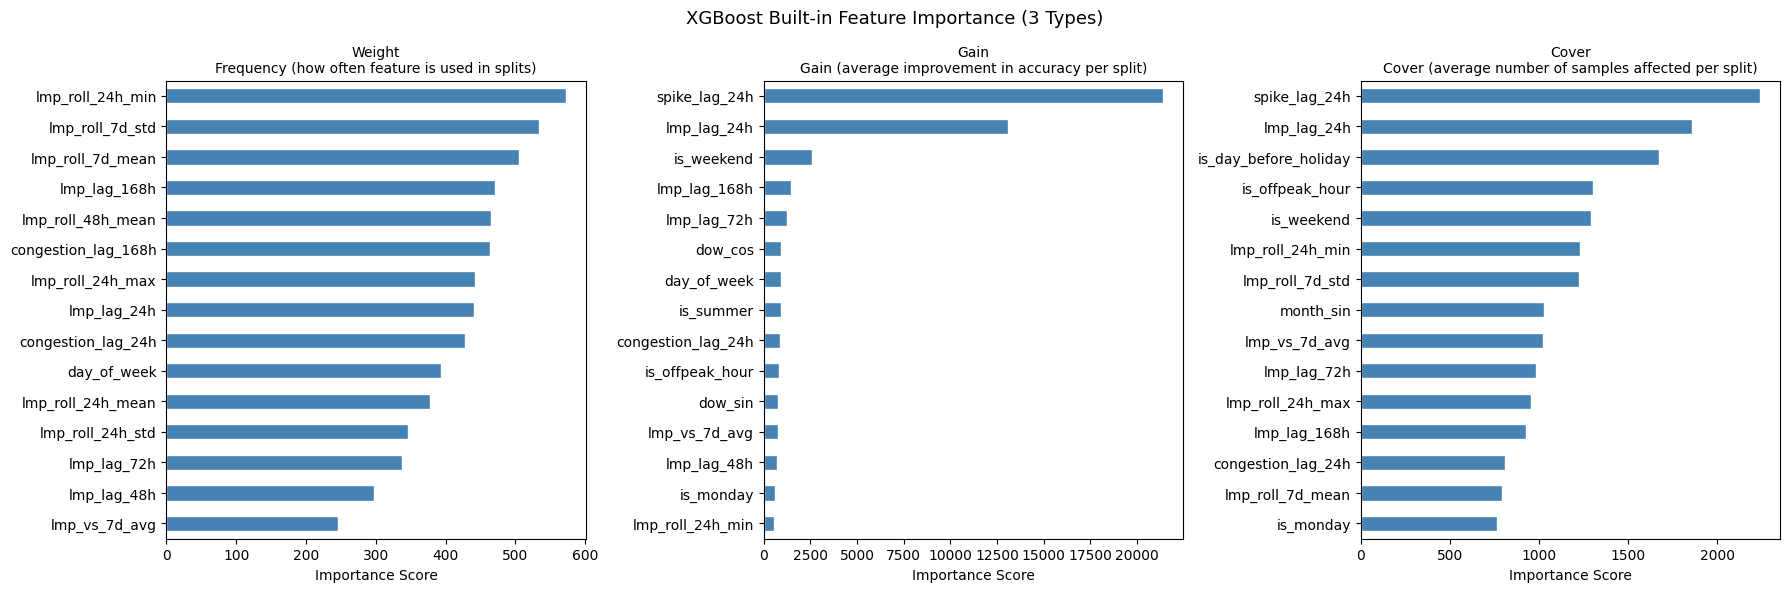

In [2]:
# --- Built-in XGBoost Importance ---

# XGBoost has 3 built-in importance types
importance_types = ['weight', 'gain', 'cover']
importance_labels = {
    'weight': 'Frequency (how often feature is used in splits)',
    'gain':   'Gain (average improvement in accuracy per split)',
    'cover':  'Cover (average number of samples affected per split)'
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, imp_type in zip(axes, importance_types):
    imp = pd.Series(
        model.get_booster().get_score(importance_type=imp_type)
    ).sort_values(ascending=True).tail(15)  # Top 15

    imp.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(f'{imp_type.capitalize()}\n{importance_labels[imp_type]}',
                 fontsize=10)
    ax.set_xlabel('Importance Score')

plt.suptitle('XGBoost Built-in Feature Importance (3 Types)', fontsize=13)
plt.tight_layout()
plt.savefig('results/xgb_builtin_importance.png', dpi=150)
plt.show()

### Chart 1 — Built-in Importance (3 Types)
Notice the disagreement between the three panels:
**Weight (left)**: `lmp_roll_24h_min` used most frequently in splits — but frequency doesn't mean importance, just that it's a useful splitting point at many levels of the tree.
**Gain (middle)**: `spike_lag_24h` and `lmp_lag_24h` dominate massively — these two features produce the biggest accuracy improvements per split. This is the most meaningful of the three built-in types.
**Cover (right)**: `spike_lag_24h` again — it affects the most samples per split, meaning it's acting as a high-level gate early in the trees.
**The lesson**: Built-in importance types disagree with each other. This is exactly why SHAP is better — it gives one consistent, mathematically grounded answer.

Built-in importance has a flaw — it doesn't tell you direction or magnitude. SHAP fixes both.

In [3]:
# --- SHAP Values ---

# SHAP TreeExplainer is optimized for tree-based models
explainer   = shap.TreeExplainer(model)

# Calculate SHAP values on test set
# Use a sample of 2000 rows for speed — still statistically representative
sample_idx  = np.random.choice(len(X_test), size=2000, replace=False)
X_sample    = X_test.iloc[sample_idx]

print("Calculating SHAP values... (takes ~30 seconds)")
shap_values = explainer.shap_values(X_sample)
print(f"SHAP values shape: {shap_values.shape}")
print("Done.")

Calculating SHAP values... (takes ~30 seconds)
SHAP values shape: (2000, 33)
Done.


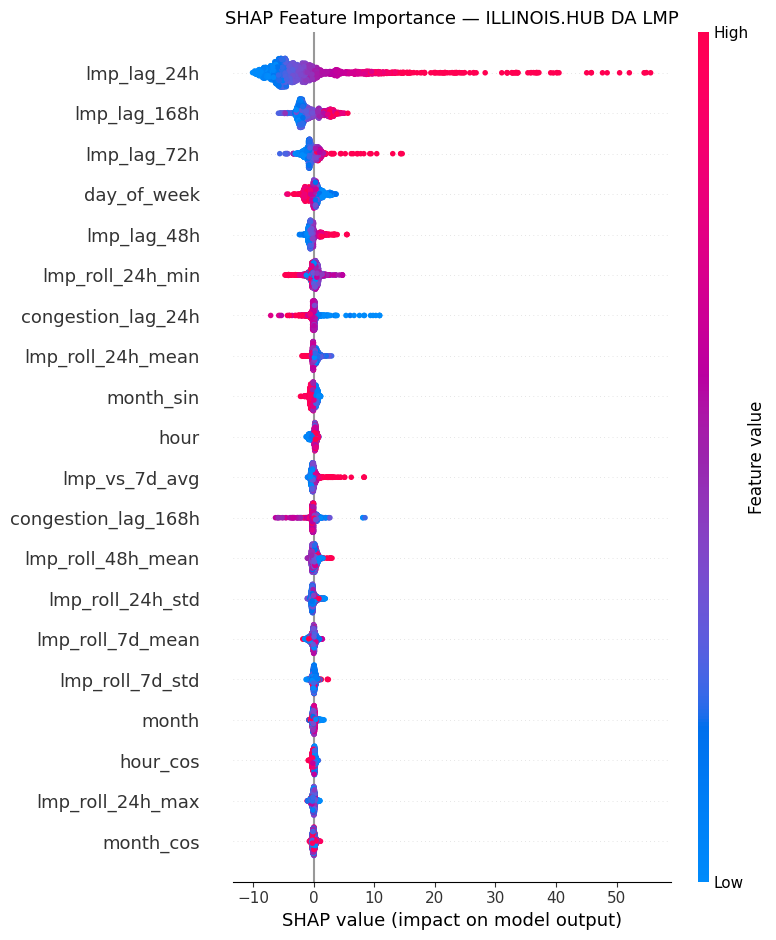

In [5]:
# --- SHAP Summary Plot ---

# Summary plot — the most important SHAP visualization
# Each dot = one prediction
# X axis = how much that feature pushed price up or down
# Color = feature value (red=high, blue=low)

plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values,
    X_sample,
    feature_names=FEATURES,
    max_display=20,
    show=False
)
plt.title('SHAP Feature Importance — ILLINOIS.HUB DA LMP', fontsize=13)
plt.tight_layout()
plt.savefig('results/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

### Chart 2 — SHAP Summary Plot (The Most Informative)
Read this carefully — each row is a feature, each dot is one prediction hour:

`lmp_lag_24h` **— Dominant, Massive Range**

- Red dots (high yesterday price) push predictions far right (+$20 to +$55)
- Blue dots (low yesterday price) push predictions left (-$5 to -$10)
- The dots stretch all the way to +$55 — those are the polar vortex hours where yesterday's high price correctly signaled "today will also be expensive"
- Translation: Yesterday's price is by far the strongest signal your model uses

`lmp_lag_168h` **— Strong but Narrower**

- Same direction as lag_24h but compressed range (±$10)
-Weekly seasonality working correctly

`day_of_week` **— Bidirectional**

- Red dots (high day number = weekend) push left (lower price)
- Blue dots (low day number = weekday) push right (higher price)
- This is exactly the weekday/weekend gap you saw in Phase 2 EDA

`congestion_lag_24h` **— Interesting Outliers**

- A few blue dots far left — yesterday's negative congestion correctly predicts lower prices today
- Confirms congestion signal has real predictive value despite being noisy

`month_sin` and `hour` **— Seasonal and Daily Patterns**

- Both show bidirectional effects
- Confirms the model learned the seasonal and daily curves from Phase 2

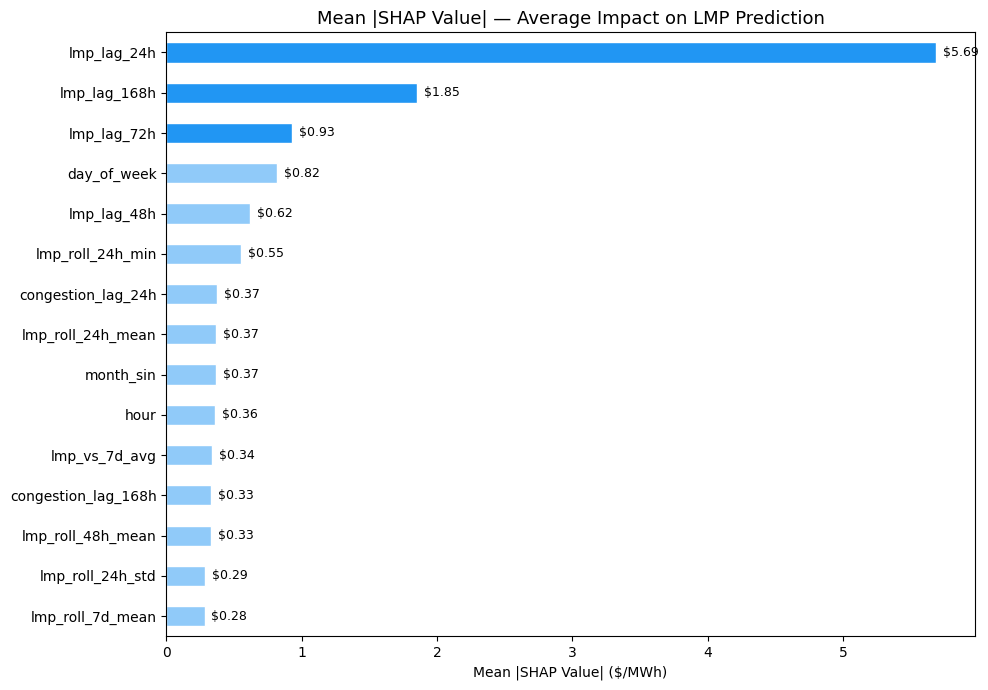

In [6]:
# SHAP Bar Plot (Mean Absolute Impact)

# Mean absolute SHAP value per feature
# Cleaner ranking than the dot plot
shap_mean = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=FEATURES
).sort_values(ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#2196F3' if i >= len(shap_mean)-3 
          else '#90CAF9' for i in range(len(shap_mean))]
shap_mean.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.set_title('Mean |SHAP Value| — Average Impact on LMP Prediction',
             fontsize=13)
ax.set_xlabel('Mean |SHAP Value| ($/MWh)')

# Add value labels
for i, (val, name) in enumerate(zip(shap_mean.values, shap_mean.index)):
    ax.text(val + 0.05, i, f'${val:.2f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('results/shap_bar.png', dpi=150)
plt.show()

### Chart 3 - SHAP Bar Plot (Clean Ranking)
```
#1  lmp_lag_24h     $5.69/MWh  ← 3x more important than #2
#2  lmp_lag_168h    $1.85/MWh
#3  lmp_lag_72h     $0.93/MWh
#4  day_of_week     $0.82/MWh
#5  lmp_lag_48h     $0.62/MWh
```
**The Answer to "What Drives Your Model?"**
**Price momentum dominates.** The top 3 features are all lagged LMP values — the model is primarily saying "tomorrow's price will look a lot like recent prices, adjusted for day of week and season."

The feature groups ranked by total SHAP impact:
|Group |Features in Top 15| Interpretation|
|------|------------------|---------------|
|Lag LMP| 4 features|Price momentum is #1 driver|
|Temporal|4 features|Hour, day, month patterns|
|Rolling stats| 5 features|Recent market context|
|Congestion lags|2 features|Transmission signal|

<Figure size 1000x500 with 0 Axes>

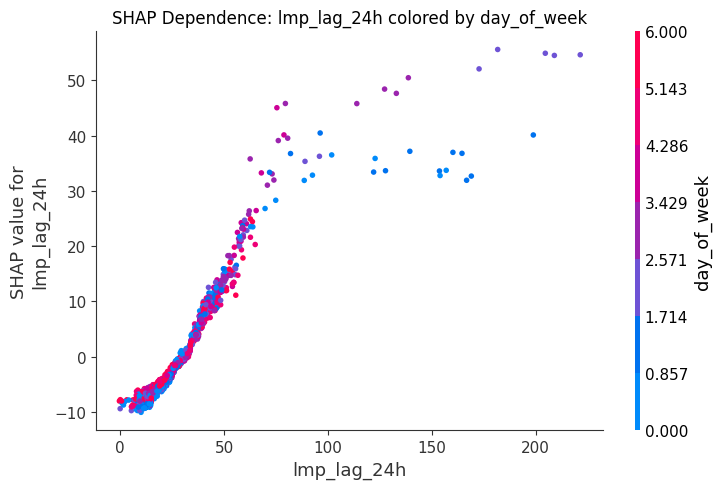

In [9]:
# --- One Final SHAP Plot: Dependence Plot ---
# This shows exactly HOW `lmp_lag_24h` affects predictions

plt.figure(figsize=(10, 5))
shap.dependence_plot(
    'lmp_lag_24h',
    shap_values,
    X_sample,
    interaction_index='day_of_week',
    show=False
)
plt.title("SHAP Dependence: lmp_lag_24h colored by day_of_week", fontsize=12)
plt.tight_layout()
plt.savefig('results/shap_dependence.png', dpi=150)
plt.show()

### Reading the SHAP Dependence Plot
**X-axis**: The actual value of `lmp_lag_24h` (yesterday's price, $/MWh)
**Y-axis**: How much that feature pushed today's prediction up or down
Color: Day of week (blue = Monday=0, red = Sunday=6)

### Three Distinct Regions: 
**Region 1 — Low Prices ($0–$50, the dense cluster)**
- Tight linear relationship — when yesterday was cheap, today is predicted cheap
- SHAP contribution ranges from -$10 to +$10
- Colors mixed evenly — day of week doesn't matter much when prices are normal
- Translation: In normal markets, yesterday's price is a reliable, stable signal

**Region 2 — Medium Prices ($50–$80, the steep jump)**
- SHAP values jump sharply from +$10 to +$30
- This is the "elevated market" regime — prices above normal trigger a non-linear response
- The model has learned that $50+ yesterday means something unusual is happening
- Translation: The relationship is non-linear — XGBoost correctly learned that high prices beget high prices more than proportionally

**Region 3 — Extreme Prices ($80–$220, the scattered dots)**
- Wide spread of SHAP values ($30–$55)
- Critically — blue dots cluster lower, red/pink dots cluster higher
- Blue = weekday (Monday), Red = weekend (Saturday/Sunday)
- When yesterday's price was extreme AND it's a weekend, the model predicts even higher
- Those $200+ dots on the far right are the polar vortex hours

### The Key Interaction Effect
The color pattern in Region 3 reveals something genuinely interesting:

Extreme price + Weekend → Even higher SHAP contribution
Extreme price + Weekday → Slightly lower SHAP contribution

This seems counterintuitive — weekdays are normally more expensive. But during extreme events like polar vortex, residential heating load dominates and doesn't drop on weekends the way industrial load does. So weekend extreme prices are actually stickier.
This is an interaction effect that simple linear models completely miss. XGBoost found it automatically.